In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import seaborn as sns
import contextily as cx
from libpysal import weights
import matplotlib.pyplot as plt

from esda.moran import Moran, Moran_Local
from splot.esda import moran_scatterplot

In [2]:
hex_gdf = gpd.read_file("preprocessed data/hex_listing_aggregates_epsg25832.geojson")

hex_gdf.head()
hex_gdf.crs
hex_gdf.columns

Index(['h3_id', 'listing_count', 'median_price', 'mean_price', 'min_price',
       'max_price', 'accommodates_mean', 'accommodates_median',
       'bedrooms_mean', 'bedrooms_median', 'beds_mean', 'beds_median',
       'bathrooms_mean', 'bathrooms_median', 'distance_to_center_km_mean',
       'distance_to_center_km_median', 'geometry'],
      dtype='str')

In [3]:
# Queen contiguity weights
w_queen = weights.Queen.from_dataframe(hex_gdf)
w_queen.transform = "r"

print("Number of hexes:", w_queen.n)
print("Average neighbours:", w_queen.mean_neighbors)
print("Islands:", w_queen.islands)

Number of hexes: 162
Average neighbours: 5.222222222222222
Islands: []


C:\Users\kubic\AppData\Local\Temp\ipykernel_8084\1586352421.py:2: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w_queen = weights.Queen.from_dataframe(hex_gdf)


In [18]:
# Number of neighbours for each hexagon
neighbor_counts = [len(neigh) for neigh in w_queen.neighbors.values()]

print("Minimum neighbours:", min(neighbor_counts))
print("Maximum neighbours:", max(neighbor_counts))

Minimum neighbours: 2
Maximum neighbours: 6


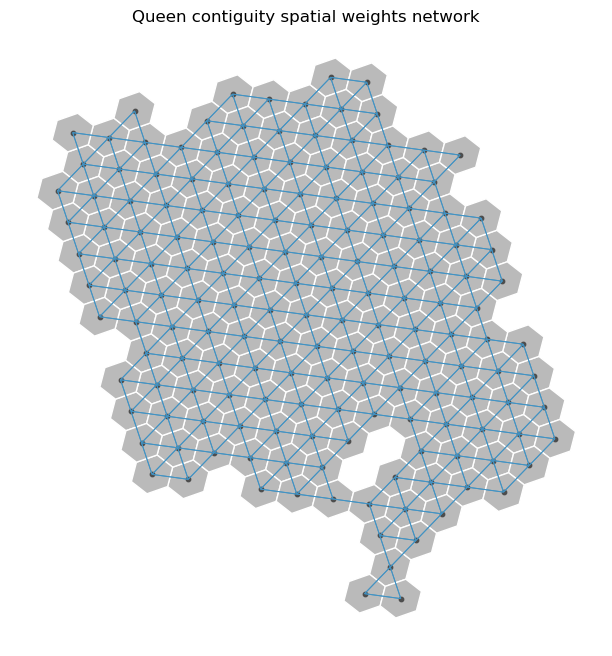

In [20]:
# sanity check for the weights
from splot.libpysal import plot_spatial_weights

fig, ax = plt.subplots(figsize=(8,8))

hex_gdf.plot(
    facecolor="lightgrey",
    edgecolor="white",
    linewidth=0.5,
    ax=ax
)

plot_spatial_weights(
    w_queen,
    hex_gdf,
    ax=ax
)

ax.set_title("Queen contiguity spatial weights network")
ax.set_axis_off()

plt.show()

## Global Morans I

In [6]:
y = hex_gdf["median_price"].values

moran_queen = Moran(y, w_queen, permutations=999)

print("Moran's I:", moran_queen.I)
print("p-value:", moran_queen.p_sim)

Moran's I: 0.329956514875096
p-value: 0.001


## Local Spatial Autocorrelation (LISA)

In [7]:
lisa = Moran_Local(y, w_queen)
hex_gdf["lisa_cluster"] = lisa.q
hex_gdf["lisa_p"] = lisa.p_sim
hex_gdf[["median_price", "lisa_cluster", "lisa_p"]].head()

,median_price,lisa_cluster,lisa_p
0,1223.0,1,0.092
1,1035.0,3,0.267
2,1201.5,1,0.214
3,1170.0,1,0.174
4,1201.5,1,0.321


Filter significant clusters 

In [8]:
hex_gdf["significant"] = hex_gdf["lisa_p"] < 0.05

hex_gdf["cluster"] = 0
hex_gdf.loc[hex_gdf["significant"], "cluster"] = hex_gdf["lisa_cluster"]

In [9]:
# Checking how many significant clusters we have
hex_gdf["significant"].sum()

np.int64(46)

In [10]:
hex_gdf["cluster"].value_counts()

cluster
0    116
3     23
1     17
4      3
2      3
Name: count, dtype: int64

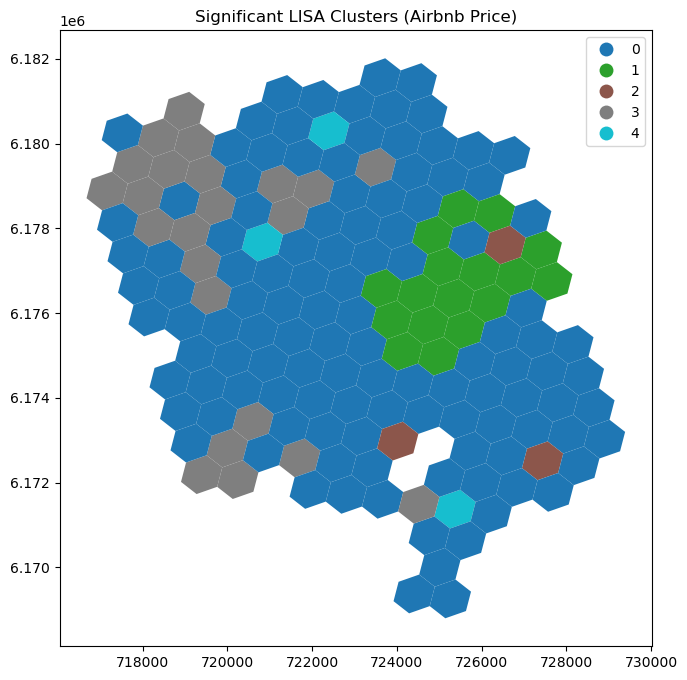

In [11]:
fig, ax = plt.subplots(figsize=(8,8))

hex_gdf.plot(column="cluster",
             categorical=True,
             legend=True,
             ax=ax)

plt.title("Significant LISA Clusters (Airbnb Price)")
plt.show()

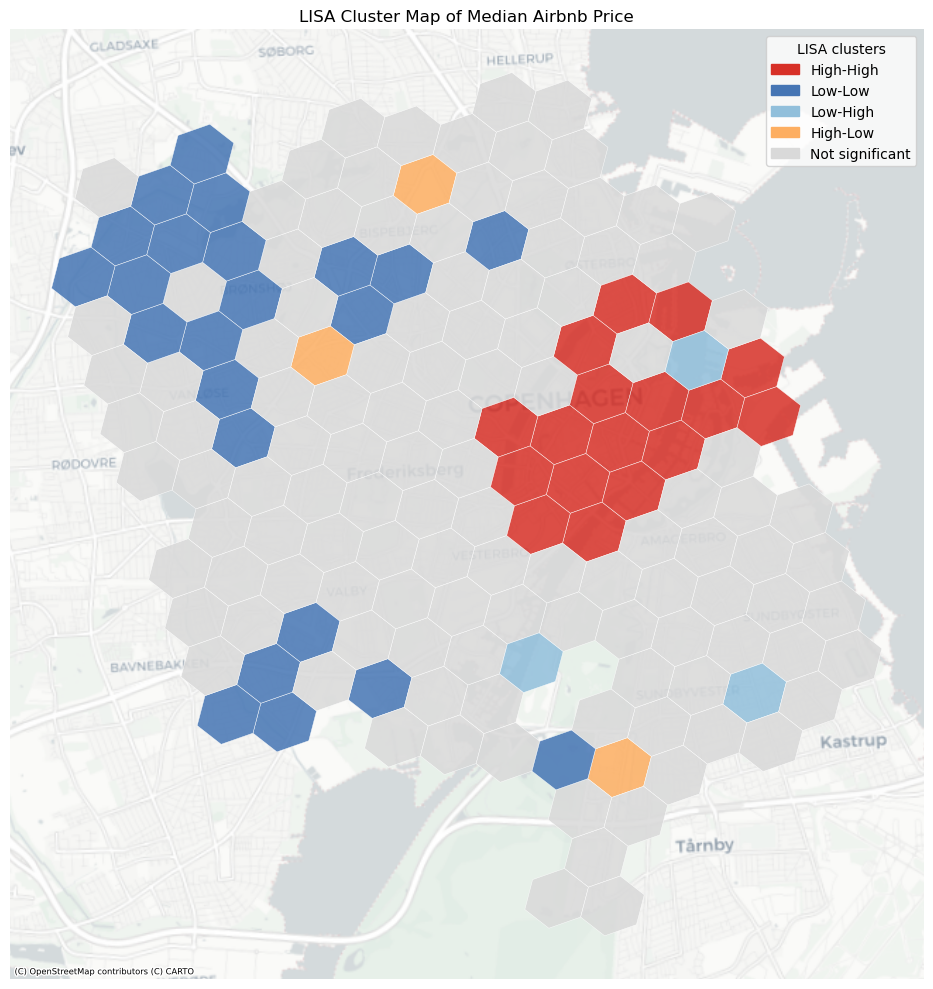

In [19]:
import matplotlib.patches as mpatches
import contextily as cx

labels = {
    0: "Not significant",
    1: "High-High",
    2: "Low-High",
    3: "Low-Low",
    4: "High-Low"
}

colors = {
    "Not significant": "#d9d9d9",
    "High-High": "#d73027",
    "Low-Low": "#4575b4",
    "Low-High": "#91bfdb",
    "High-Low": "#fdae61"
}

hex_gdf["cluster_label"] = hex_gdf["cluster"].map(labels)
hex_gdf["cluster_color"] = hex_gdf["cluster_label"].map(colors)

fig, ax = plt.subplots(figsize=(10, 10))

hex_gdf.plot(
    color=hex_gdf["cluster_color"],
    edgecolor="white",
    linewidth=0.35,
    alpha=0.85,
    ax=ax
)

cx.add_basemap(
    ax,
    crs=hex_gdf.crs,
    source=cx.providers.CartoDB.Positron,
    attribution_size=6
)

legend_patches = [
    mpatches.Patch(color=colors["High-High"], label="High-High"),
    mpatches.Patch(color=colors["Low-Low"], label="Low-Low"),
    mpatches.Patch(color=colors["Low-High"], label="Low-High"),
    mpatches.Patch(color=colors["High-Low"], label="High-Low"),
    mpatches.Patch(color=colors["Not significant"], label="Not significant"),
]

ax.legend(handles=legend_patches, title="LISA clusters", loc="upper right")
ax.set_axis_off()
ax.set_title("LISA Cluster Map of Median Airbnb Price")

plt.tight_layout()
plt.show()

Significance map

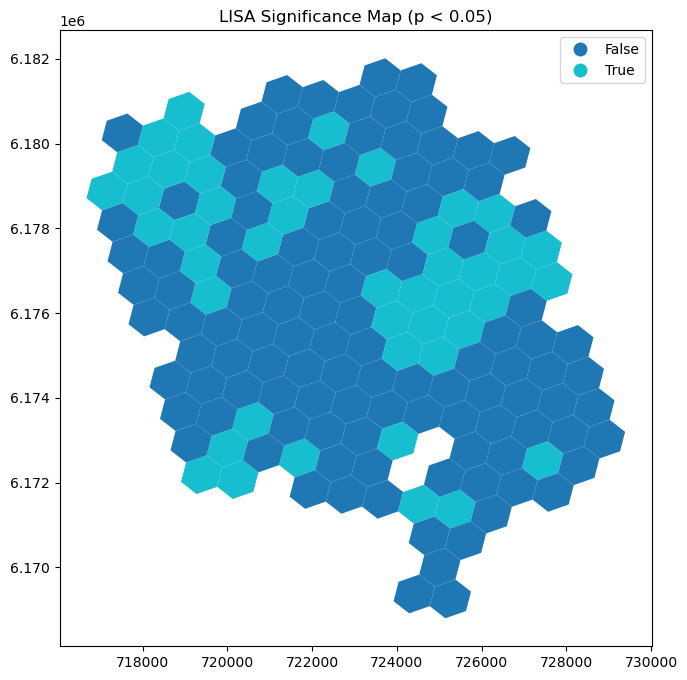

In [13]:
fig, ax = plt.subplots(figsize=(8,8))

hex_gdf.plot(column="significant",
             categorical=True,
             legend=True,
             ax=ax)

plt.title("LISA Significance Map (p < 0.05)")
plt.show()

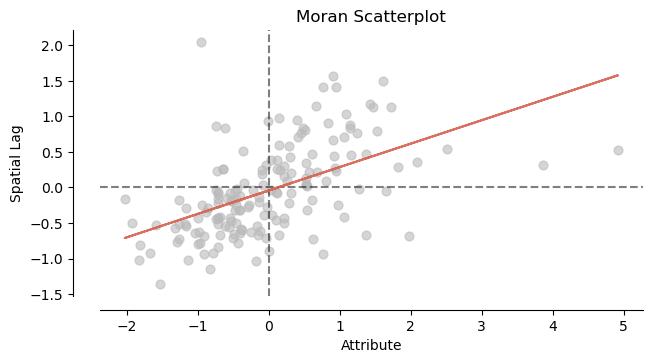

In [14]:
moran_scatterplot(lisa)
plt.title("Moran Scatterplot")
plt.show()

KNN

In [15]:
w_knn = weights.KNN.from_dataframe(hex_gdf, k=6)
w_knn.transform = "r"

print("KNN neighbours:", w_knn.mean_neighbors)
print("Islands:", w_knn.islands)

KNN neighbours: 6.0
Islands: []


In [16]:
moran_knn = Moran(y, w_knn, permutations=999)

print("KNN Moran's I:", moran_knn.I)
print("KNN p-value:", moran_knn.p_sim)

KNN Moran's I: 0.30873946799125207
KNN p-value: 0.001


In [17]:
# Save LISA columns for clustering notebook
out = hex_gdf[["h3_id", "lisa_cluster", "lisa_p", "cluster_label"]].rename(
    columns={"cluster_label": "lisa_label"}
)
out.to_parquet("preprocessed data/hex_with_lisa.parquet", index=False)
print("hex_with_lisa.parquet saved")

hex_with_lisa.parquet saved
